# 04 - Analiza eksploracyjna

## Cel: 
Zbadanie sezonowości poziomu wody, zależności między warunkami meteorologicznymi a poziomem wody oraz analizy opóźnień reakcji rzeki na opad przed budowaniem algorytmu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')

from src.data.preprocessing import build_main_df
from src.visualization.plots import *

final = build_main_df()
print("Kształt danych:", final.shape)
final.head()

Kształt danych: (1826, 38)


,Opad_suma,Temp_średnia,Temp_min,Temp_max,Wilgotność_średnia,Ciśnienie_średnia,Ciśnienie_min,Ciśnienie_max,month,sezon,...,Temp_średnia_lag_1d,Opad_24h,Opad_72h,Opad_7d,Poziom_wody_średnia,Poziom_wody_max,Martwa_Wisla_średnia,Martwa_Wisla_max,Port_Polnocny_średnia,Port_Polnocny_max
Data,,,,,,,,,,,,,,,,,,,,,
2021-01-01,0.00,-1.170833,-2.2,-0.2,94.341667,1005.466667,1005.0,1006.6,1,zima,...,0.000000,0.00,2.08,28.35,-0.052917,0.00,-0.242500,-0.20,5.061250,5.10
2021-01-02,0.00,0.616667,-0.3,2.3,87.733333,1011.208333,1007.0,1015.7,1,zima,...,-1.170833,0.00,2.08,28.35,-0.035833,0.00,-0.230417,-0.19,5.076250,5.12
2021-01-03,2.08,0.558333,-0.8,1.6,91.033333,1016.716667,1015.9,1017.4,1,zima,...,0.616667,2.08,2.08,28.35,0.013333,0.05,-0.179167,-0.14,5.140417,5.20
2021-01-04,3.61,1.245833,0.6,1.9,90.575000,1016.441667,1015.9,1016.9,1,zima,...,0.558333,3.61,5.69,28.35,0.015417,0.06,-0.182917,-0.14,5.145833,5.20
2021-01-05,18.58,2.170833,0.9,3.6,91.354167,1013.233333,1009.3,1016.3,1,zima,...,1.245833,18.58,24.27,28.35,0.018750,0.10,-0.184167,-0.11,5.149167,5.24


## 1. Sezonowość poziomu wody

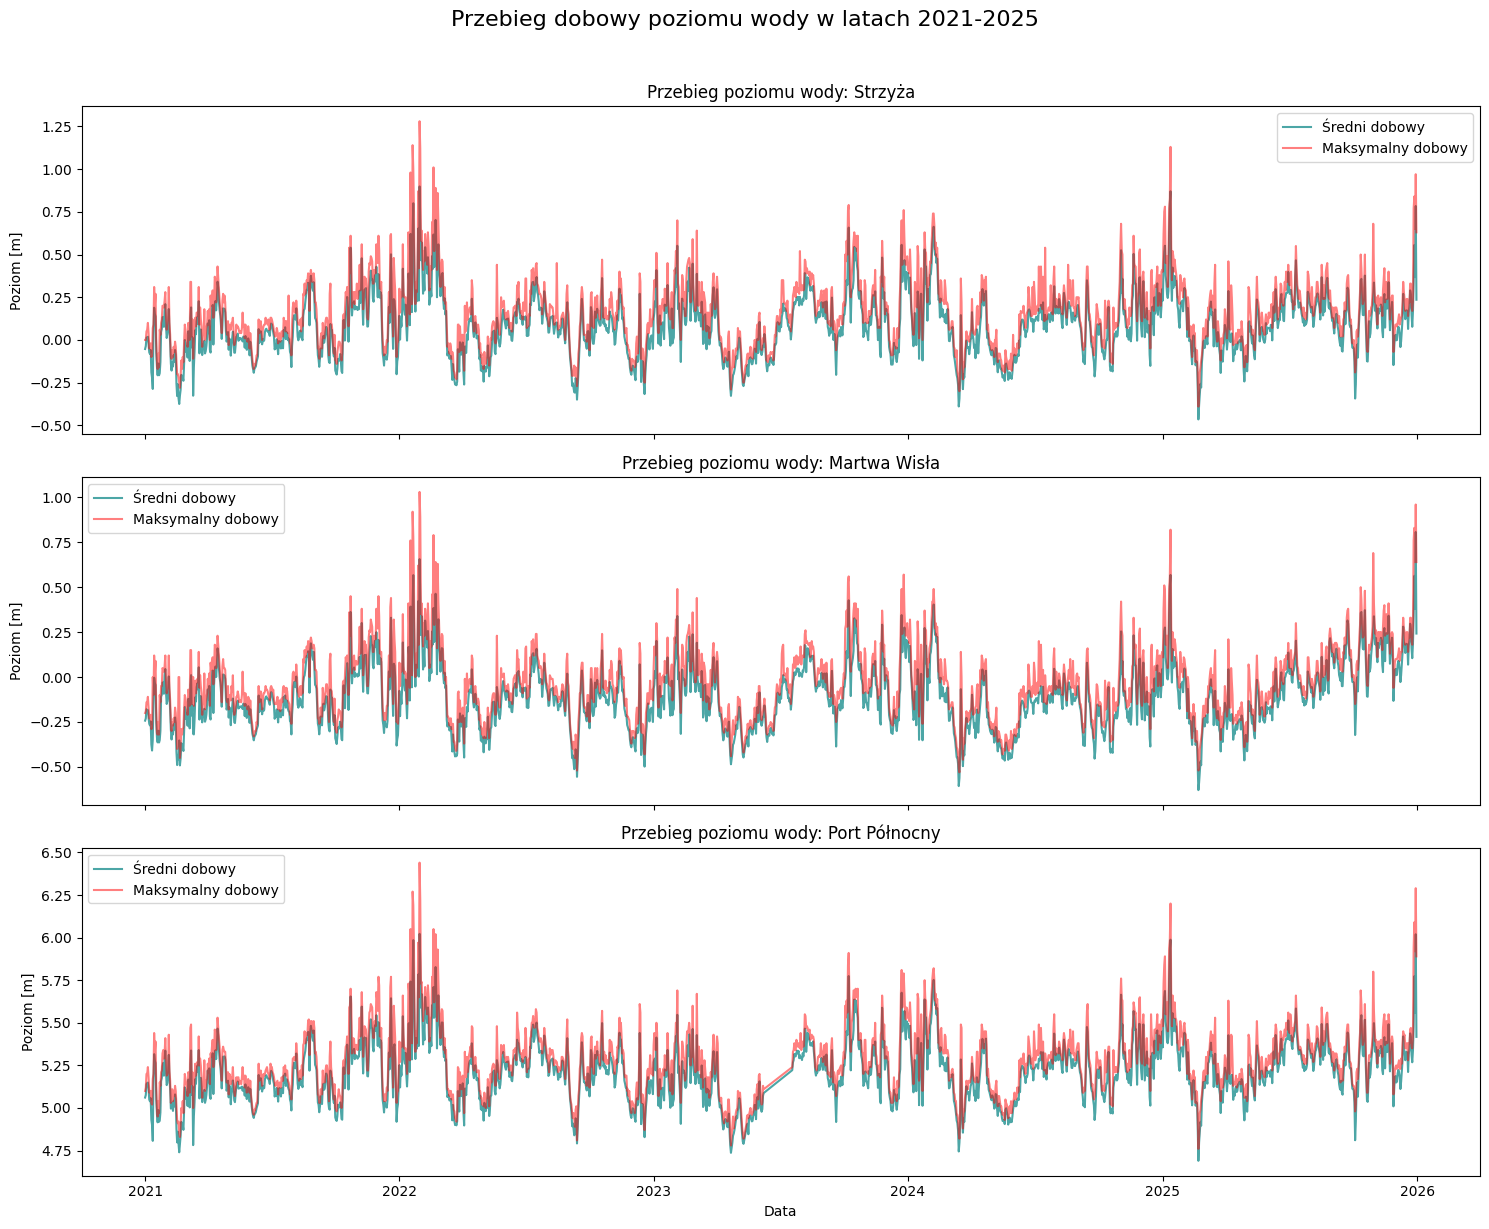

In [2]:
plot_przebieg_dobowy(final)

### Obserwacje
- Poziom wody wykazuje regularne wahania sezonowe w całym okresie 2021-2025
- Najwyższe wezbrania (~1.3m) wystąpiły na początku 2022 roku
- Wezbrania mają charakter krótkotrwały, szybki wzrost i opadanie poziomu wody
- Poziom wody jest zazwyczaj w przedziale -0.5m - 0.5m

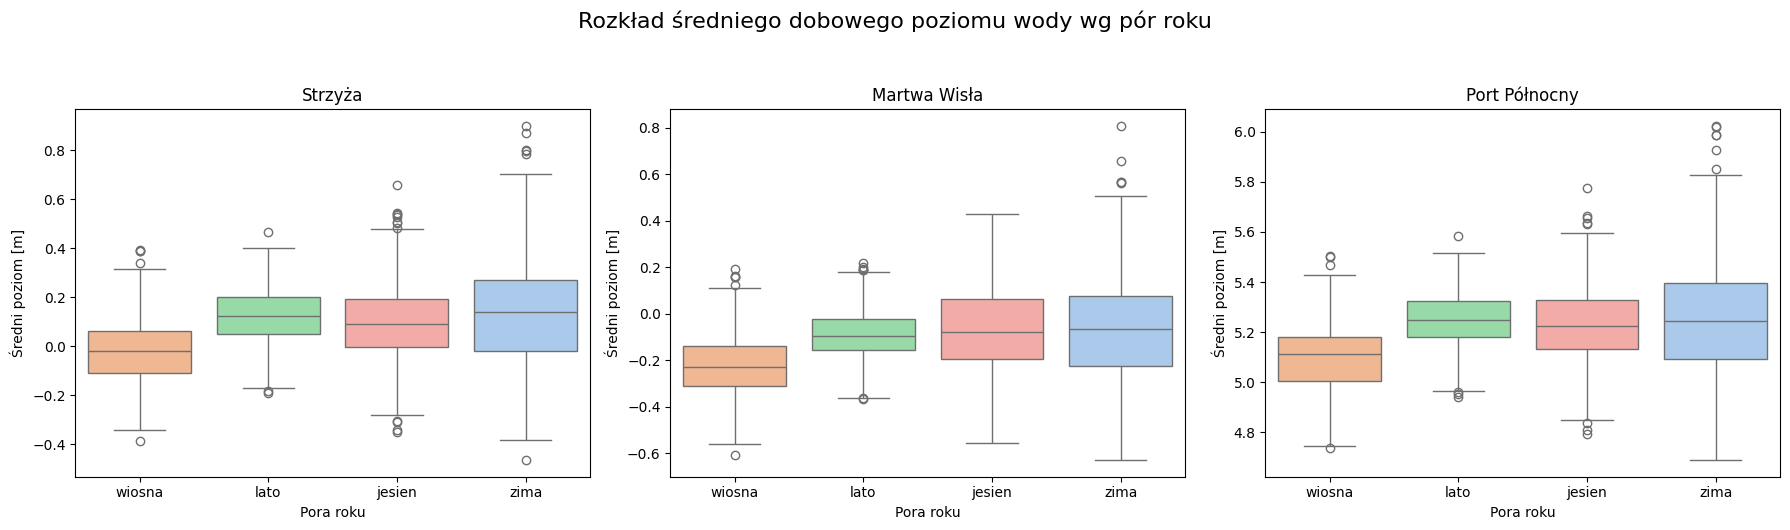

In [3]:
plot_sezonowosc_pory_roku(final)

### Obserwacje
- Wiosna ma najniższy poziom wody (mediana ~0m)
- Lato i zima mają najwyższe mediany (~0.15m)
- Zima ma największy rozrzut wartości, najbardziej zmienny okres
- Wartości odstające najliczniejsze w zimie i lecie

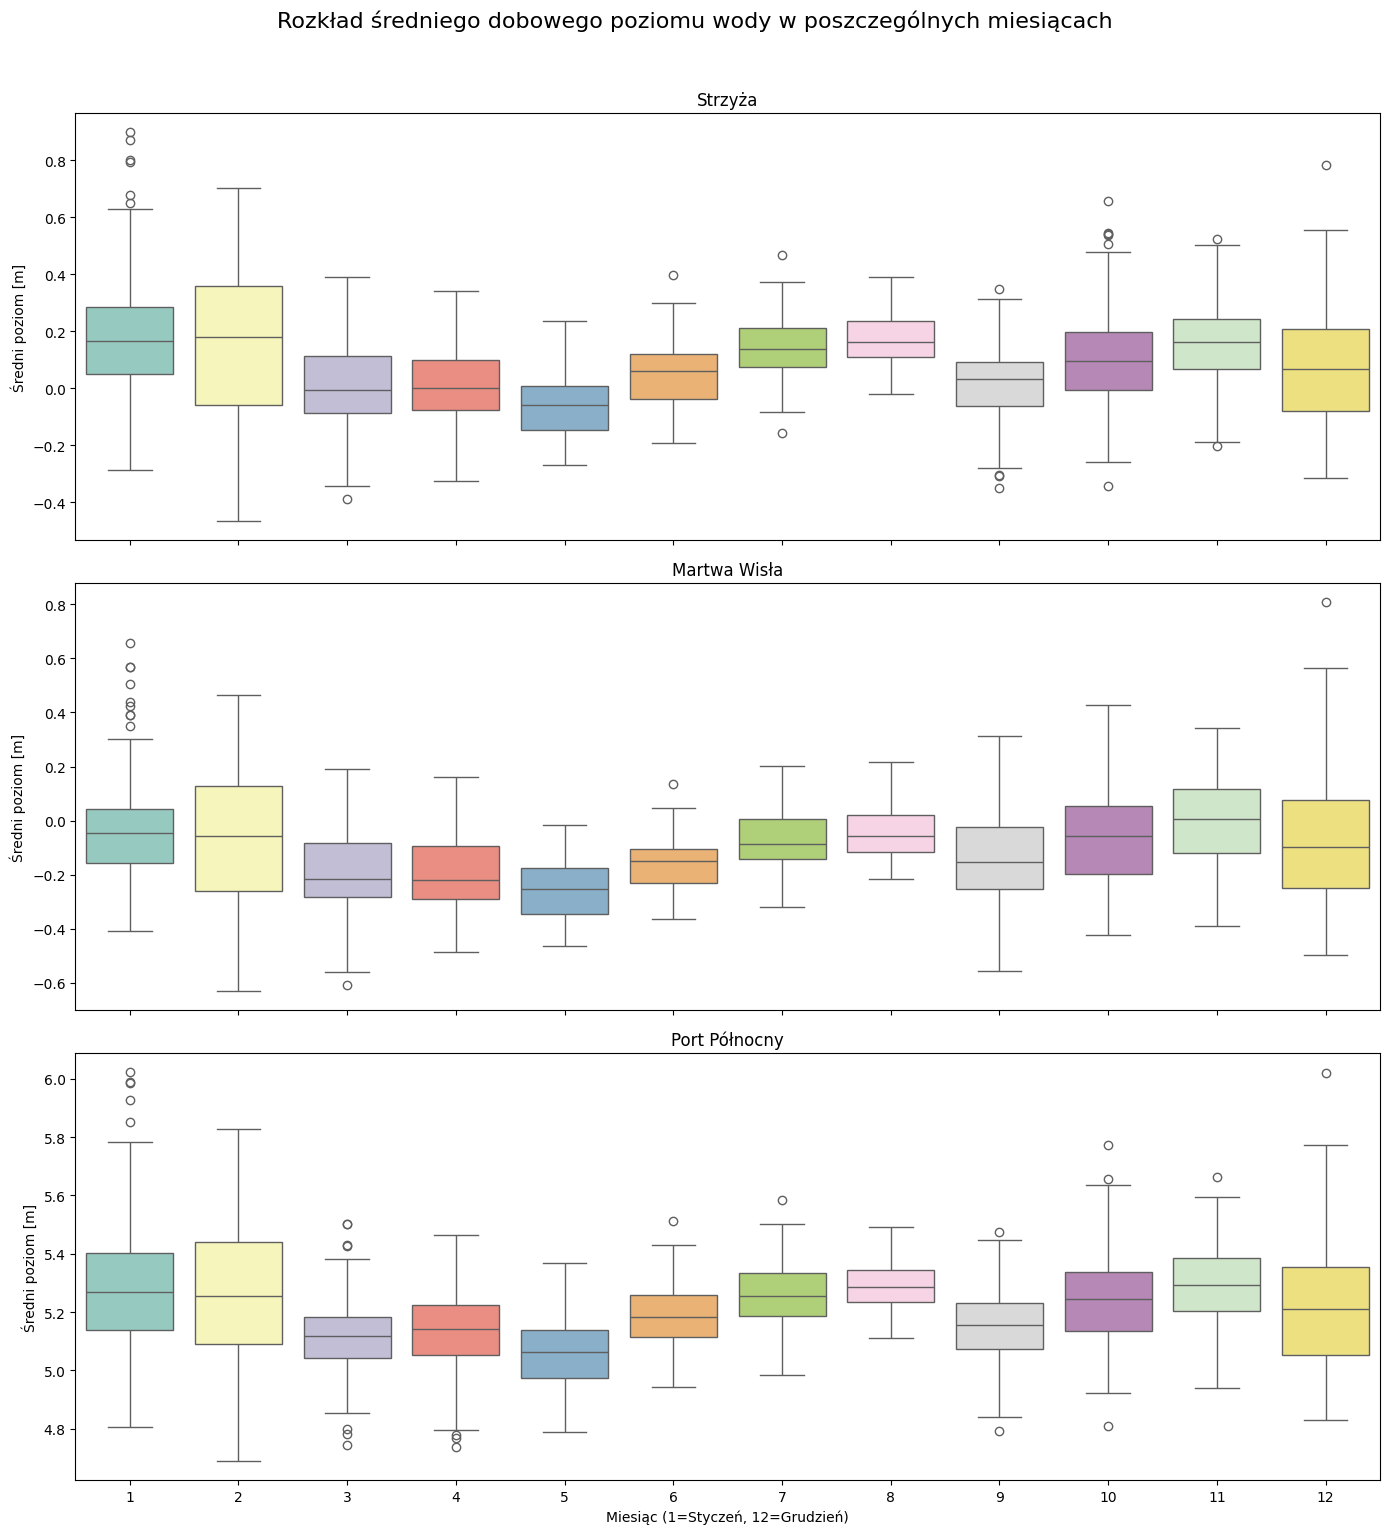

In [4]:
plot_sezonowosc_miesiace(final)

### Obserwacje
- Styczeń i luty -> najwyższe mediany (ok. 0.15-0.2m)
- Maj -> absolutne minimum poziomu wody
- Widoczny wzrost od maja do lipca, potem spadek we wrześniu
- Anomalie (punkty odstające) największe w styczniu (~0.8-0.9m)

## Podsumowanie analizy sezonowości poziomu wody
- **Miesiące o najwyższym stanie wód:** Najwyższe mediany poziomu wody notowane są w sezonie **zimowym**, ze szczególnym uwzględnieniem   **stycznia i lutego**. W warunkach gdańskich (ujście rzeki) może to być bezpośrednio związane z zimowymi układami niżowymi, sztormami i zjawiskiem tzw. "cofki" wiatrowej od strony morza, a także z opadami i ewentualnymi roztopami.
- **Miesiące niżówkowe:** Wbrew intuicji, najniższe stany wód (zarówno pod kątem średnich, jak i wartości minimalnych) charakteryzują na tej rzece **wiosnę**, osiągając absolutne minimum w **maju** (miesiąc 5). Prawdopodobnie wynika to z mniejszej sumy opadów połączonej z intensywnym poborem wody przez budzącą się do życia roślinność w zlewni.
- **Występowanie anomalii (ekstremów):** Analiza wartości odstających (punktów powyżej tzw. wąsów na wykresach pudełkowych) wskazuje, że najbardziej skrajne odchylenia od normy dla średniego poziomu dobowego występują w **styczniu** (wartości rzędu 0,8–0,9 m). Zima jest zatem okresem najbardziej dynamicznym hydrologicznie. Warto również zauważyć, że choć lato ma wyższą medianę niż wiosna czy jesień, to po usunięciu szumu pomiarowego nie wykazuje już tak drastycznych anomalii uśrednionego poziomu dobowego, co sugeruje, że letnie opady burzowe mają charakter bardzo krótkotrwały i nie podnoszą średniej dobowej tak mocno, jak długotrwałe niże zimowe.

## 2. Zależności poziom wody - meteo

### Zależność ogólna: opad skumulowany a poziom wody

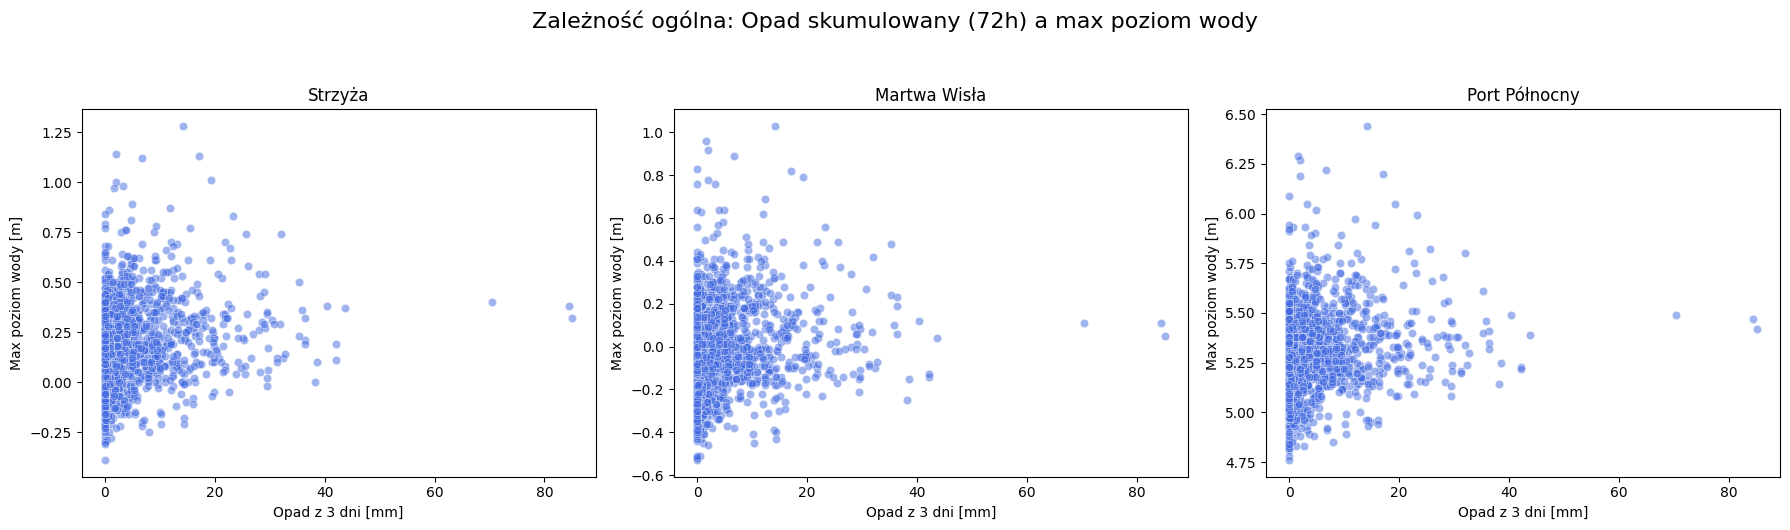

In [5]:
plot_zaleznosc_opad_woda(final)

### Obserwacje
- Gęste skupisko punktów przy Opad_72h ≈ 0mm, większość dni jest bezdeszczowa
- Najwyższe poziomy wody (>0.75m) występują przy zerowym lub małym opadzie, czyli opad nie jest głównym czynnikiem wezbrań
- Przy wysokich opadach (>40mm) poziom wody jest umiarkowany (0.2-0.5m), letnie ulewy nie powodują ekstremalnych wezbrań
- Widoczny słaby trend wzrostowy, wraz z opadem poziom wody nieznacznie rośnie, ale rozrzut jest bardzo duży
- Wniosek: zależność opad -> poziom wody jest słaba i nieliniowa

### Zależność z podziałem na pory roku

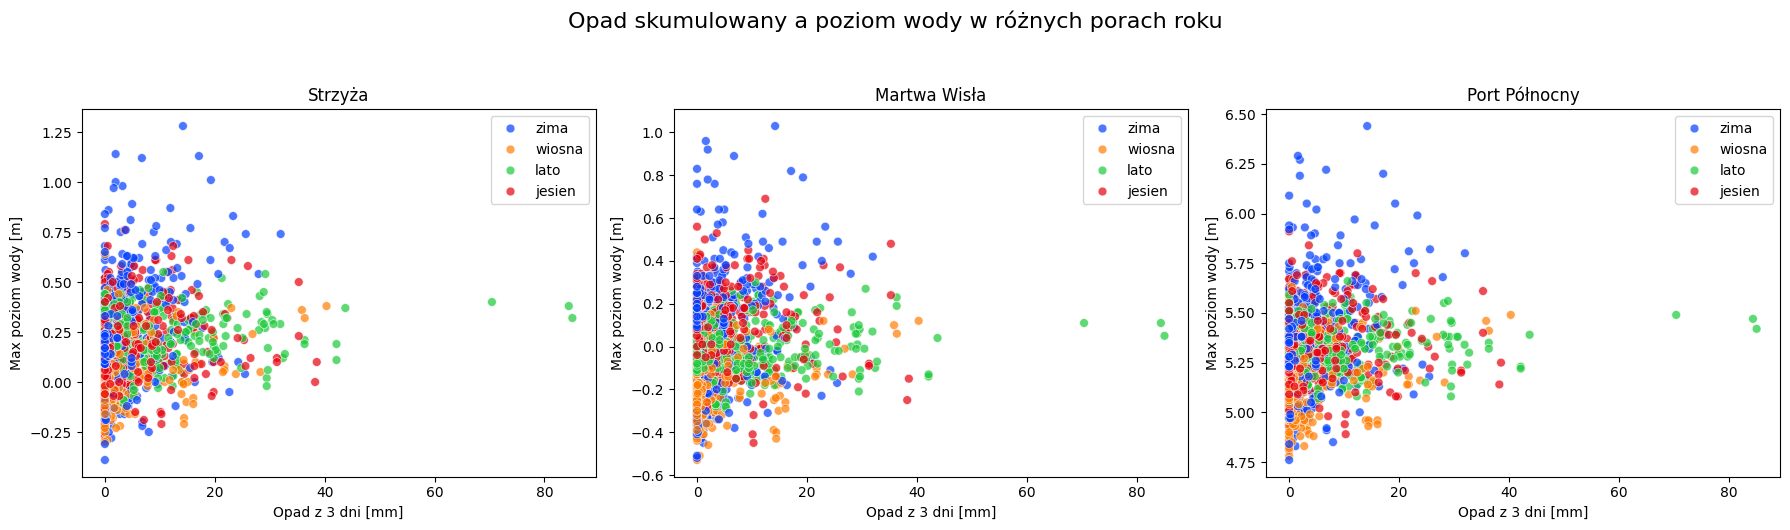

In [6]:
plot_zaleznosc_opad_woda_sezony(final)

### Obserwacje
- Zima (niebieski) - najwyższe poziomy wody (>0.75m), występują przy zerowym opadzie - potwierdzenie że zimowe wezbrania mają genezę morską (cofka), nie opadową
- Lato (zielony) — największe sumy opadów (>40-80mm/72h) ale poziom wody umiarkowany (0.2-0.4m) — letnie ulewy nie powodują ekstremalnych wezbrań
- Wiosna (pomarańczowy)— niskie poziomy wody niezależnie od opadu — zgodne z obserwacją że wiosna to okres niżówkowy
- Jesień (czerwony) — zachowanie pośrednie między zimą a latem
- Wniosek: mechanizm wezbrań jest różny w różnych porach roku —zimą dominuje cofka morska, latem opady burzowe

### Wpływ ciśnienia na poziom wody

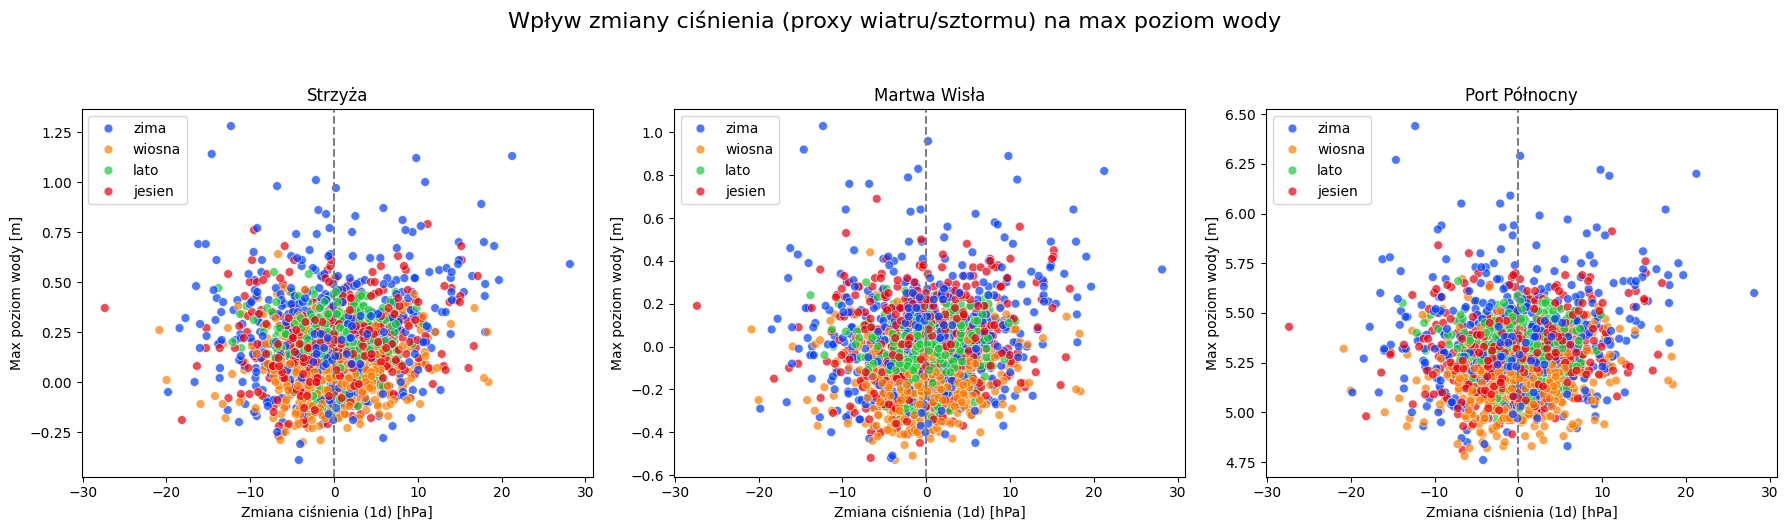

In [7]:
plot_zaleznosc_cisnienie_woda(final)

### Obserwacje
- Przy stabilnym ciśnieniu (delta ≈ 0 hPa) poziom wody skupiony w wąskim przedziale, przy dużej dynamice ciśnienia rozrzut rośnie
- Najwyższe poziomy wody (>0.75m) występują głównie przy dużych spadkach ciśnienia (lewa strona, delta < -10 hPa) i są prawie wyłącznie zimowe (niebieskie)
- Gwałtowny spadek ciśnienia = nadciągający głęboki niż = silne wiatry = zjawisko cofki morskiej
- Lato (zielony) — skupione przy delta ≈ 0, poziomy wody umiarkowane — brak wpływu cofki latem
- Wniosek: dynamika ciśnienia jest lepszym predyktorem ekstremalnych wezbrań niż opad — szczególnie zimą

## Podsumowanie zależności poziom wody – warunki meteorologiczne
**Wpływ opadów skumulowanych (72h)**

- Absolutnie najwyższe stany wód (powyżej 0,75 m) występują najczęściej w dniach o znikomym lub zerowym opadzie skumulowanym — opad atmosferyczny nie jest głównym czynnikiem napędzającym ekstremalne wezbrania na rzece Strzyża
- Bardzo wysokie sumy opadów (>60–80 mm/72h) występują niemal wyłącznie latem i wywołują wzrost poziomu wody do ok. 0,3–0,5 m, jednak nie zbliżają się do rocznych maksimów

**Wpływ dynamiki ciśnienia atmosferycznego**

- Wykres przyjmuje charakterystyczny kształt lejka — im większa dynamika ciśnienia, tym większy rozrzut poziomu wody
- Ekstremalne wezbrania występują przy silnych wahaniach ciśnienia (10–20 hPa/dobę) głównie zimą
- Wskazuje to że ekstremalne wezbrania mają genezę morską (sztormową), a nie opadową — silne wiatry "wtłaczają" wodę z Zatoki Gdańskiej w górę koryta Strzyży

## 3. Czasowe reakcje na opad (opóźnienia / lags)

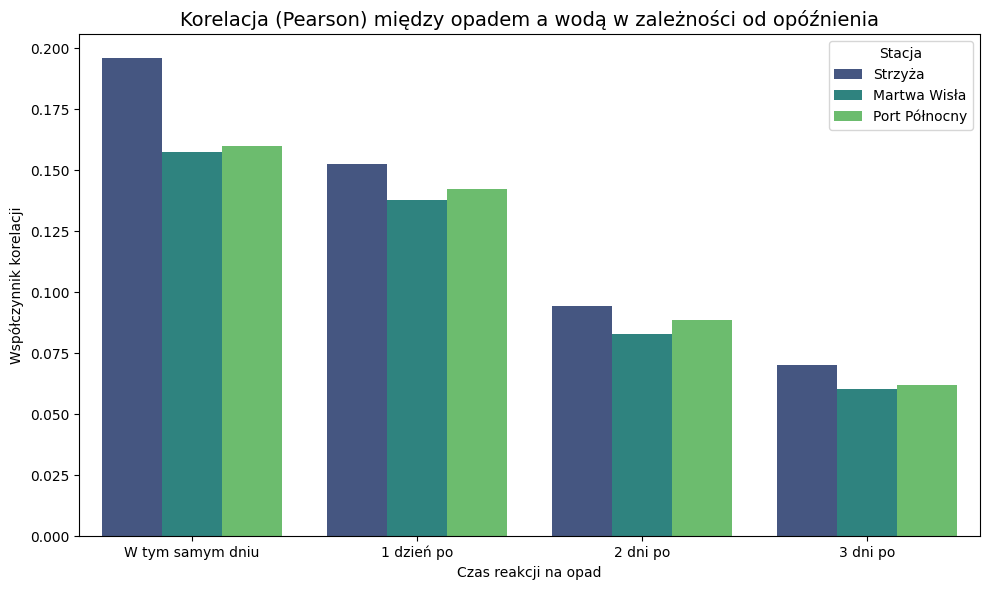

In [8]:
plot_korelacja_opoznien(final)

### Obserwacje
- Najwyższa korelacja (r ≈ 0.19) dla opadu w tym samym dniu, rzeka reaguje bardzo szybko, w ciągu kilku godzin
- Korelacja spada z każdym dniem:
  - Lag 0: r ≈ 0.196
  - Lag 1: r ≈ 0.153
  - Lag 2: r ≈ 0.095
  - Lag 3: r ≈ 0.071
- Krótki czas reakcji to cecha zlewni silnie zurbanizowanej. Oznacza to że woda deszczowa nie wsiąka w grunt lecz błyskawicznie trafia do koryta przez kanalizację burzową
- Wszystkie wartości korelacji są niskie (r < 0.2), potwierdza że opad nie jest głównym czynnikiem wezbrań

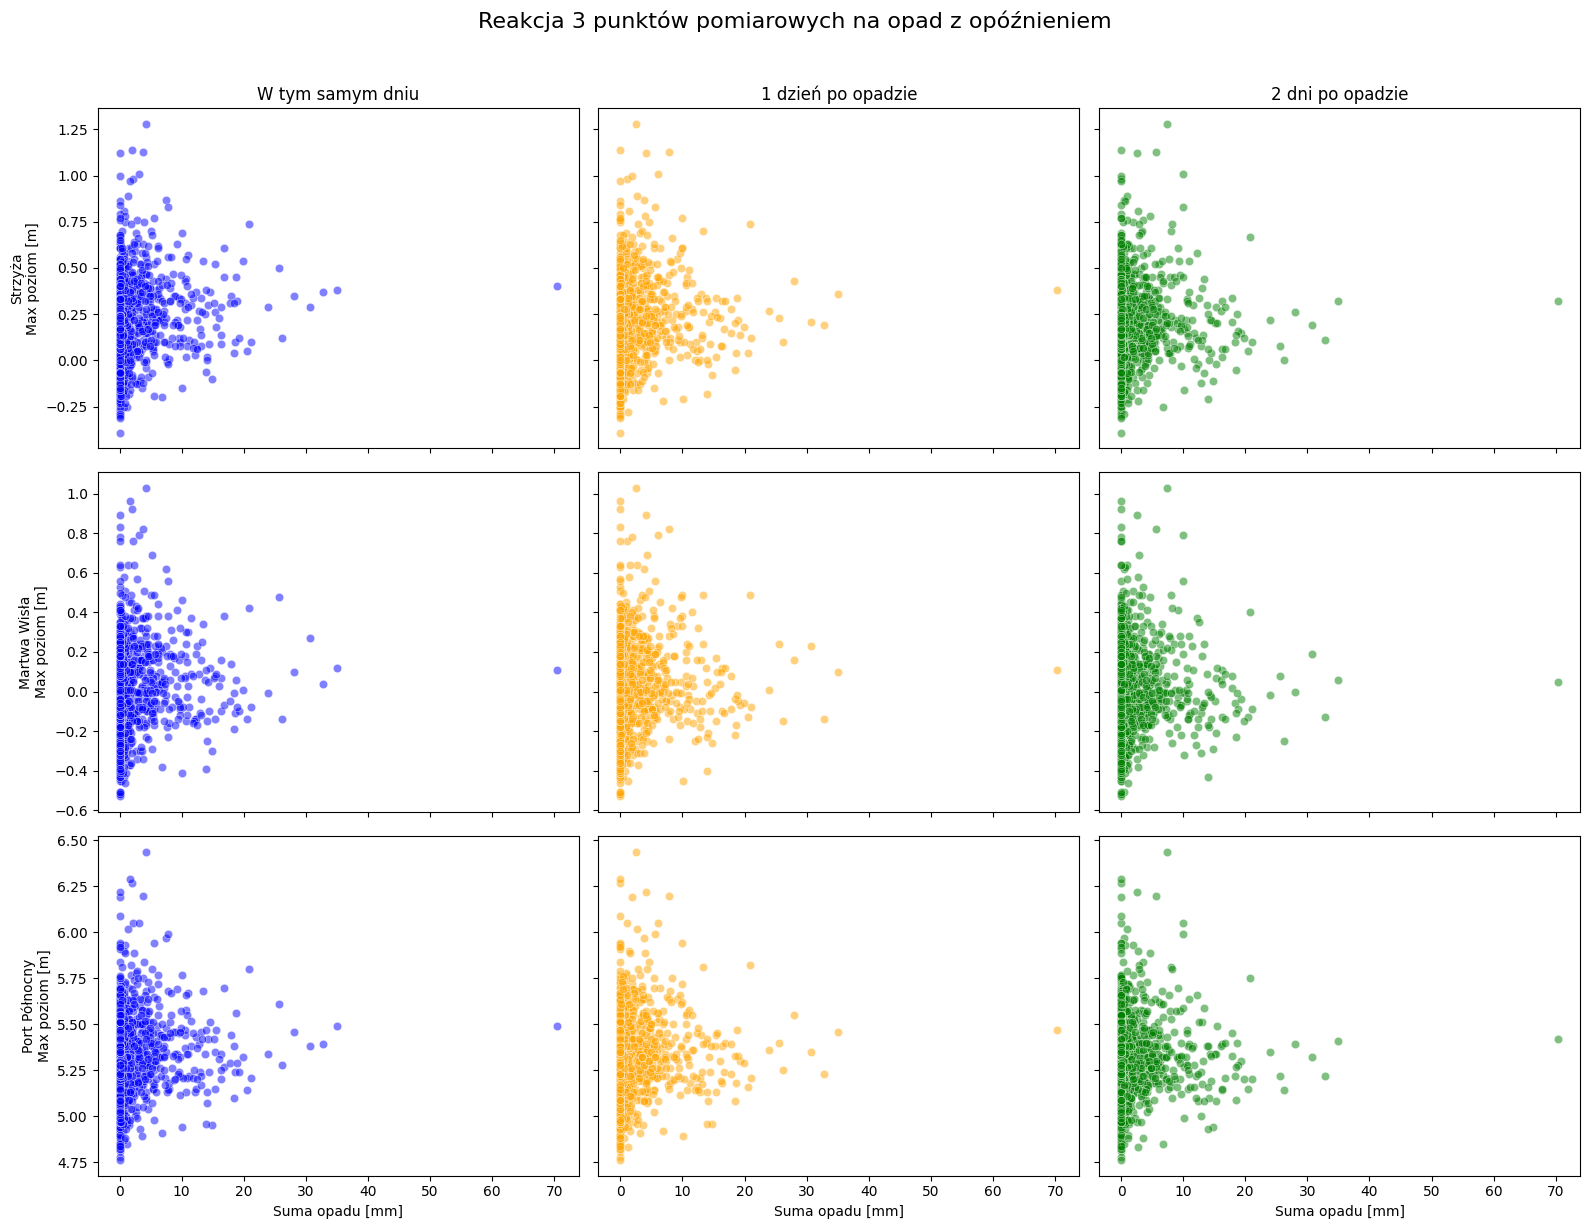

In [9]:
plot_scatter_opoznienia(final)

### Obserwacje
- We wszystkich trzech panelach najwyższe poziomy wody (>0.75m) grupują się przy zerowym lub minimalnym opadzie, potwierdza genezę morską ekstremalnych wezbrań
- Wraz z rosnącym opóźnieniem widoczne jest zawężanie się chmury punktów, czyli mniej dni z wysokim opadem pozostaje w korelacji z wysokim poziomem wody
- Trend wzrostowy jest słaby we wszystkich wykresach
- Wniosek: rzeka reaguje najsilniej tego samego dnia co opad, reakcja z opóźnieniem jest malutka

## Podsumowanie analizy opóźnień

1. **Szybka reakcja rzeki** — najsilniejsza korelacja (r ≈ 0.196) dla opadu w tym samym dniu, kaskadowo malejąca z każdym kolejnym dniem (lag 1: 0.153, lag 2: 0.095, lag 3: 0.071)

2. **Cecha zlewni zurbanizowanej** — krótki czas koncentracji odpływu wynika z dużego uszczelnienia terenu (asfalt, beton, dachy) w gdańskich dzielnicach — woda nie wsiąka w grunt lecz trafia do koryta przez kanalizację burzową

3. **Niskie wartości korelacji** (r < 0.2) przy wszystkich opóźnieniach — ostateczne potwierdzenie że opady powodują natychmiastowe ale umiarkowane wzrosty poziomu wody

4. **Ekstremalne wezbrania** generowane są od strony ujścia przez cofkę wiatrową wpychającą wodę z Zatoki Gdańskiej, nie przez opady atmosferyczne

## Podsumowanie analizy eksploracyjnej
Kluczowe wnioski:

### Sezonowość
- Najwyższe poziomy wody w **zimie** (styczeń/luty)
- Najniższe poziomy wody **wiosną** (maj)
- Zima najbardziej dynamiczny okres

### Zależności meteo - poziom wody
- **Opad nie jest głównym czynnikiem** ekstremalnych wezbrań
- **Ciśnienie atmosferyczne** jest lepszym predyktorem, gwałtowne spadki ciśnienia poprzedzają wezbrania zimowe
- Dwa różne mechanizmy wezbrań:
  - **Zima** → cofka morska (zjawisko sztormowe)
  - **Lato** → krótkotrwałe ulewy (umiarkowane wzrosty)

### Analiza opóźnień
- Rzeka reaguje na opad **tego samego dnia** (cecha zlewni zurbanizowanej)
- Korelacja słaba (r < 0.2) — opad wyjaśnia mały procent zmienności poziomu wody

### Główny wniosek
Rzeka Strzyża zachowuje się nietypowo — ekstremalne wezbrania mają genezę **morską**, nie opadową. Kluczowym czynnikiem ryzyka są zimowe sztormy i cofka z Zatoki Gdańskiej.